# 1. Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/Loan_default.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 1.1 Tổng quan về Dataset

Các tổ chức tài chính phải đối mặt với những thách thức lớn trong việc quản lý rủi ro tín dụng và giảm thiểu nợ xấu khoản vay. Việc dự đoán liệu người vay có khả năng default khoản vay hay không là một nhiệm vụ quan trọng, giúp các bên cho vay đưa ra quyết định sáng suốt, tối thiểu hóa tổn thất tài chính và cải thiện chiến lược quản lý rủi ro.

Trong dự án này, nhóm sử dụng Loan Default Prediction Dataset, một tập dữ liệu có nguồn gốc từ cuộc thi Loan Default Prediction Challenge trên Coursera. Dataset này đại diện cho bài toán đánh giá rủi ro tín dụng thực tế và được sử dụng rộng rãi để phát triển, đánh giá các mô hình machine learning trong việc dự đoán default khoản vay.

Dataset chứa thông tin về đặc điểm nhân khẩu học, tình trạng tài chính, lịch sử việc làm, hồ sơ tín dụng và các thuộc tính khoản vay của người vay. Mục tiêu là dự đoán liệu người vay có bị default khoản vay hay không dựa trên các features này.

## 1.2 Đặc trưng của Dataset

- Số lượng observations: **255,347**
- Số lượng variables: **18**
- Số lượng input features: **17**
- Target variable: **Default**

### Mô tả feature
Dataset bao gồm các numerical và categorical features mô tả đặc điểm của người vay và thông tin khoản vay.

| Feature | Type | Description |
|----------|----------|----------|
| LoanID | Identifier | Mã định danh duy nhất cho mỗi khoản vay |
| Age | Numerical | Tuổi của người vay |
| Income | Numerical | Thu nhập hàng năm của người vay |
| LoanAmount | Numerical | Tổng số tiền vay |
| CreditScore | Numerical | Điểm tín dụng thể hiện mức độ uy tín tín dụng của người vay |
| MonthsEmployed | Numerical | Số tháng người vay đã làm việc |
| NumCreditLines | Numerical | Số lượng hạn mức tín dụng đang hoạt động |
| InterestRate | Numerical | Lãi suất áp dụng cho khoản vay |
| LoanTerm | Numerical | Kỳ hạn vay tính bằng tháng |
| DTIRatio | Numerical | Tỷ lệ Nợ trên Thu nhập (Debt-to-Income Ratio) |
| Education | Categorical | Trình độ học vấn cao nhất đạt được |
| EmploymentType | Categorical | Tình trạng việc làm |
| MaritalStatus | Categorical | Tình trạng hôn nhân |
| HasMortgage | Categorical | Biểu thị liệu người vay có tài sản thế chấp hay không |
| HasDependents | Categorical | Biểu thị liệu người vay có người phụ thuộc hay không |
| LoanPurpose | Categorical | Mục đích của khoản vay |
| HasCoSigner | Categorical | Biểu thị liệu khoản vay có người đồng ký tên hay không |
| Default | Target | Loan default status (Trạng thái default khoản vay (1 = Default, 0 = Non-default)) |

### Phân nhóm Feature

Để phục vụ cho việc thấu hiểu và giải thích mô hình tốt hơn, các features có thể được phân thành các nhóm danh mục sau:

- Danh mục Nhân khẩu học: `Age`, `MaritalStatus`, `Education`

- Danh mục Tài chính: `Income`, `LoanAmount`, `DTIRatio`

- Danh mục Lịch sử tín dụng: `CreditScore`, `NumCreditLines`

- Danh mục Việc làm: `EmploymentType`, `MonthsEmployed`

- Đặc điểm Khoản vay: `InterestRate`, `LoanTerm`, `LoanPurpose`, `HasCoSigner`

- Đặc điểm Hộ gia đình: `HasMortgage`, `HasDependents`

Các nhóm feature này được kỳ vọng sẽ đóng góp khác nhau vào kết quả dự đoán của mô hình và sau này sẽ được phân tích sâu hơn bằng các kỹ thuật giải thích mô hình như SHAP và TreeSHAP.

# 1.3 Thống kê mô tả

In [2]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


- Khách hàng có độ tuổi trung bình khoảng 43,5 tuổi, trong đó độ tuổi từ 18 đến 69 tuổi.
- Thu nhập hàng năm thay đổi đáng kể, dao động từ 15.000 đến 149.999, với thu nhập bình quân khoảng 82.499.
- Số tiền vay dao động từ 5.000 đến 249.999, cho thấy sự khác biệt đáng kể về nhu cầu vay vốn giữa những người nộp đơn.
- Điểm tín dụng trung bình là 574,26, với các giá trị trải dài từ 300 đến 849, cho thấy nhiều mức độ tín nhiệm khác nhau.
- Tỷ lệ Nợ trên Thu nhập (DTI) trung bình là 0,50, cho thấy trung bình người đi vay phân bổ khoảng một nửa thu nhập của mình cho các nghĩa vụ nợ.

In [3]:
df.describe(include="object")

,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,ZTH91CGL0B,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


- Hầu hết các biến phân loại có sự phân bố tương đối cân bằng giữa các danh mục.

- Vì các mô hình học máy yêu cầu đầu vào dạng số, nên các đặc trưng phân loại này sẽ được mã hóa trong giai đoạn tiền xử lý.

In [ ]:
# Kiểm tra missing values
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': round(df.isnull().sum()/len(df)*100, 2)
})

missing_data = missing_data[missing_data['Missing Count'] > 0]

if len(missing_data) > 0:
    display(missing_data)
else:
    print("Không tìm thấy giá trị nào bị thiếu trong tập dữ liệu")

Không tìm thấy giá trị nào bị thiếu trong tập dữ liệu


In [ ]:
# Phân phối của biến mục tiêu 'Default'
df['Default'].value_counts(normalize=True).mul(100).round(2)

Default
0    88.39
1    11.61
Name: proportion, dtype: float64

- Hầu hết người vay (88,39%) không vỡ nợ, trong khi chỉ có 11,61% được phân loại là người vỡ nợ.
- Tập dữ liệu cho thấy sự mất cân bằng lớp ở mức độ vừa phải, điều này cần được xem xét trong quá trình huấn luyện và đánh giá mô hình.

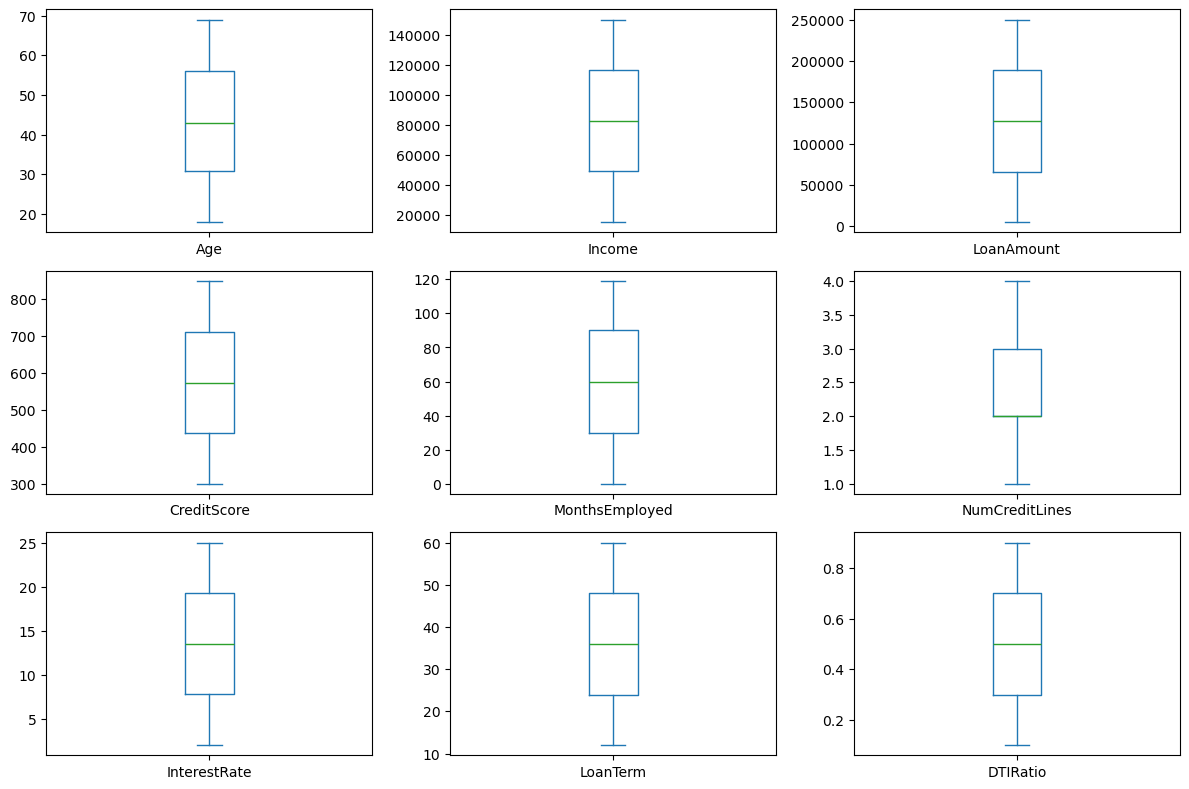

In [ ]:
# Kiểm tra outliers
numerical_cols = [
    col for col in df.select_dtypes(include='number').columns
    if col != 'Default'
]

df[numerical_cols].plot(
    kind='box',
    subplots=True,
    layout=(3,3),
    figsize=(12,8)
)

plt.tight_layout()
plt.show()

- Không phát hiện thấy giá trị ngoại lệ đáng kể nào trong các biến số định lượng.

- Hầu hết các đặc điểm đều thể hiện sự phân bố tương đối đối xứng với các giá trị nằm trong phạm vi dự kiến.

- Do đó, không cần xử lý giá trị ngoại lệ trước khi tiến hành các giai đoạn tiền xử lý và mô hình hóa.

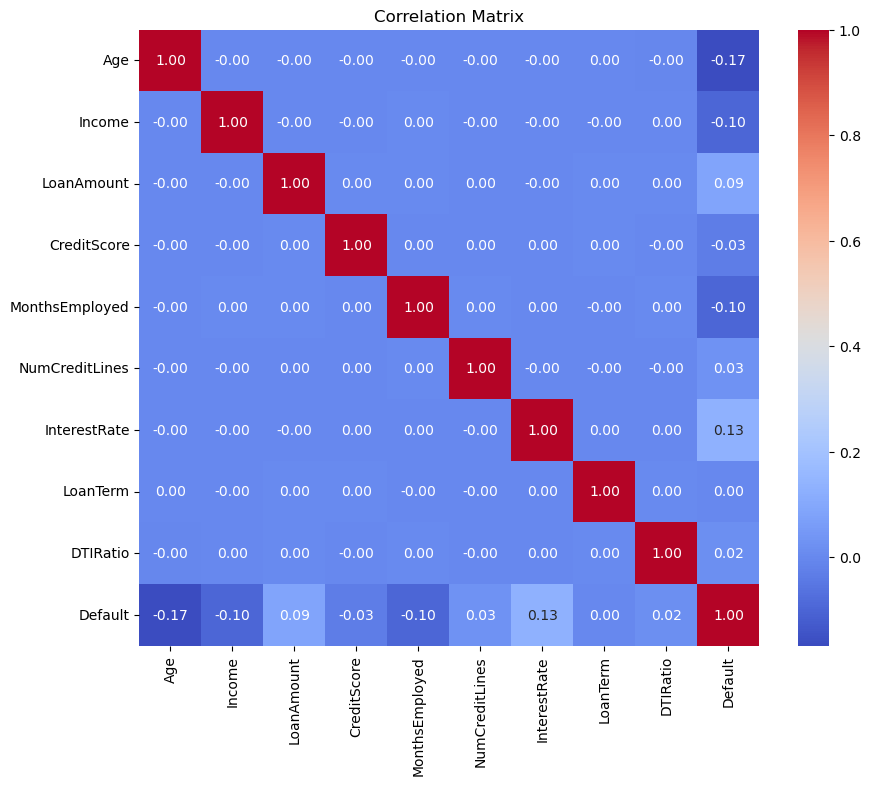

In [13]:
# Phân tích tương quan
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- **Hầu hết các đặc điểm số liệu thể hiện mối tương quan cặp rất yếu**, với hệ số tương quan gần bằng không. Điều này cho thấy hiện tượng đa cộng tuyến không phải là vấn đề đáng lo ngại trong tập dữ liệu.

- Mối tương quan âm mạnh nhất với biến mục tiêu (Default) được quan sát thấy ở Age (-0,17), cho thấy **người vay lớn tuổi hơn có xu hướng có xác suất vỡ nợ thấp hơn.**

- InterestRate (0,13) và LoanAmount (0,09) cho thấy mối tương quan dương yếu với Default, cho thấy **người vay có lãi suất cao hơn hoặc khoản vay lớn hơn có thể có khả năng vỡ nợ cao hơn một chút.**

- Vì tất cả các mối tương quan đều tương đối yếu, nên chỉ riêng mối tương quan tuyến tính có thể không giải thích đầy đủ hành vi vỡ nợ của khoản vay. Do đó, cần có các mô hình học máy tiên tiến hơn và các giải thích dựa trên SHAP để nắm bắt các mối quan hệ phức tạp và phi tuyến tính giữa các đặc điểm.

# 2. Pipeline Processing
## 2.1 Data preprocessing

Quá trình tiền xử lý bao gồm:

- Loại bỏ các biến định danh
- Mã hóa các đặc trưng phân loại
- Chuẩn bị ma trận đặc trưng và biến mục tiêu

In [ ]:
# Loại bỏ biến định danh
df = df.drop(columns=['LoanID'])

In [16]:
# Categorical Encoding
categorical_cols = df.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,False,False,False,True,True,False,False,False,True,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,True,False,False,False,False,False,False,True,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,True,False,False,True,True,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,True,False,False,False,True,False,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,True,False,False,False,True,False,False,False,False,False


In [17]:
# Feature Matrix và biến mục tiêu
X = df_encoded.drop('Default', axis=1)

y = df_encoded['Default']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (255347, 24)
y shape: (255347,)


- Sau khi áp dụng mã hóa One-Hot cho các đặc trưng phân loại, số lượng đặc trưng đầu vào đã tăng từ 17 đặc trưng ban đầu (không bao gồm LoanID và Default) lên 24 đặc trưng.

*Notes:* **Feature Scaling** không được thực hiện trong nghiên cứu này vì các mô hình học máy được chọn, bao gồm XGBoost và LightGBM, là các thuật toán dựa trên cây. Các mô hình này chia dữ liệu dựa trên ngưỡng đặc trưng chứ không phải dựa trên tính toán khoảng cách, do đó chúng không nhạy cảm với sự khác biệt về quy mô đặc trưng.

## 2.2 Train/Test Split

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (204277, 24)
Testing set: (51070, 24)


In [19]:
# Kiểm tra phân bố class
print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64

Default
0    0.883865
1    0.116135
Name: proportion, dtype: float64


- Phân bố lớp được giữ nguyên sau khi chia tập train/test.

- Khoảng 88,4% người vay không vỡ nợ, trong khi 11,6% là người vỡ nợ ở cả hai tập con.

- Lấy mẫu phân tầng giúp đảm bảo rằng tập huấn luyện và tập kiểm tra vẫn đại diện cho tập dữ liệu gốc.

In [20]:
X.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes',
       'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home',
       'LoanPurpose_Other', 'HasCoSigner_Yes'],
      dtype='object')